In [ ]:
# CMP7005 Programming for Data Analysis
## PRAC1 – From Data to Application Development

### Task 1: Data Handling
#### Importing and analyzing datasets, merging both datasets by identifying the primary key

In [1]:
# Importing pandas and numpy libraries , dispaly all columns
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)

In [2]:
# Load the loan approval dataset
dataset1 = pd.read_csv("../data/Loan_Approval_Data_Set_1.csv")
dataset2 = pd.read_csv("../data/Loan_Approval_Data_Set_2.csv")

In [3]:
# Display thr numbers of rows and columns
print("Dataset 1 shape:", dataset1.shape)
print("Dataset 2 shape:", dataset2.shape)

Dataset 1 shape: (20000, 16)
Dataset 2 shape: (20000, 18)


In [4]:
# Print column names
print("Dataset 1 columns:")
print(dataset1.columns.tolist())

print("\nDataset 2 columns:")
print(dataset2.columns.tolist())

Dataset 1 columns:
['ID', 'ApplicationDate', 'AnnualIncome', 'EmploymentStatus', 'Experience', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'NumberOfOpenCreditLines', 'BankruptcyHistory', 'PreviousLoanDefaults', 'LengthOfCreditHistory', 'CheckingAccountBalance', 'TotalLiabilities', 'NetWorth', 'LoanApproved']

Dataset 2 columns:
['ApplicationDate', 'Age', 'CreditScore', 'EducationLevel', 'Experience', 'LoanAmount', 'MaritalStatus', 'HomeOwnershipStatus', 'ID', 'CreditCardUtilizationRate', 'NumberOfCreditInquiries', 'LoanPurpose', 'PaymentHistory', 'SavingsAccountBalance', 'TotalAssets', 'JobTenure', 'InterestRate', 'RiskScore']


In [5]:
# Summary of dataset
dataset1.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   ID                       20000 non-null  str  
 1   ApplicationDate          20000 non-null  str  
 2   AnnualIncome             20000 non-null  int64
 3   EmploymentStatus         20000 non-null  str  
 4   Experience               20000 non-null  int64
 5   LoanDuration             20000 non-null  int64
 6   NumberOfDependents       20000 non-null  int64
 7   MonthlyDebtPayments      20000 non-null  int64
 8   NumberOfOpenCreditLines  20000 non-null  int64
 9   BankruptcyHistory        20000 non-null  int64
 10  PreviousLoanDefaults     20000 non-null  int64
 11  LengthOfCreditHistory    20000 non-null  int64
 12  CheckingAccountBalance   20000 non-null  int64
 13  TotalLiabilities         20000 non-null  int64
 14  NetWorth                 20000 non-null  int64
 15  LoanApproved 

In [6]:
dataset2.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ApplicationDate            20000 non-null  str    
 1   Age                        20000 non-null  int64  
 2   CreditScore                20000 non-null  int64  
 3   EducationLevel             20000 non-null  str    
 4   Experience                 19334 non-null  float64
 5   LoanAmount                 20000 non-null  int64  
 6   MaritalStatus              19985 non-null  str    
 7   HomeOwnershipStatus        20000 non-null  str    
 8   ID                         20000 non-null  str    
 9   CreditCardUtilizationRate  20000 non-null  float64
 10  NumberOfCreditInquiries    20000 non-null  int64  
 11  LoanPurpose                20000 non-null  str    
 12  PaymentHistory             20000 non-null  int64  
 13  SavingsAccountBalance      20000 non-null  int64  
 14  T

In [7]:
#Analyze row counts and verify uniqueness of the ID column
print("Dataset 1")
print("Rows:", len(dataset1))
print("Unique IDs:", dataset1["ID"].nunique())
print("Duplicate IDs:", dataset1["ID"].duplicated().sum())

print("\nDataset 2")
print("Rows:", len(dataset2))
print("Unique IDs:", dataset2["ID"].nunique())
print("Duplicate IDs:", dataset2["ID"].duplicated().sum())

Dataset 1
Rows: 20000
Unique IDs: 20000
Duplicate IDs: 0

Dataset 2
Rows: 20000
Unique IDs: 20000
Duplicate IDs: 0


In [8]:
#Check unique Id in both datasets are identical
ids_match = set(dataset1["ID"]) == set(dataset2["ID"])

print("Do both datasets contain the same IDs?", ids_match)

Do both datasets contain the same IDs? True


In [ ]:
# Merging the Datasets
### ID was chosen as the primary key to merge the datasets because it uniquely identifies records from each dataset 

In [9]:
# Identifying overlapping columns
common_columns = set(dataset1.columns).intersection(set(dataset2.columns))

print("Common columns:")
print(common_columns)

Common columns:
{'ID', 'Experience', 'ApplicationDate'}


In [10]:
# Compare the number of unique entries for shared columns except ID
for col in common_columns:
    if col != "ID":
        print(f"\nColumn: {col}")
        print("Dataset 1 unique values:", dataset1[col].nunique(dropna=False))
        print("Dataset 2 unique values:", dataset2[col].nunique(dropna=False))


Column: Experience
Dataset 1 unique values: 62
Dataset 2 unique values: 62

Column: ApplicationDate
Dataset 1 unique values: 2922
Dataset 2 unique values: 20000


In [11]:
# Inner join datasets using ID
merged_df = pd.merge(
    dataset1,
    dataset2,
    on="ID",
    how="inner",
    suffixes=("_ds1", "_ds2")
)

In [12]:
# Check first few rows of the merged dataset
print("Merged dataset shape:", merged_df.shape)
merged_df.head()

Merged dataset shape: (20000, 33)


,ID,ApplicationDate_ds1,AnnualIncome,EmploymentStatus,Experience_ds1,LoanDuration,NumberOfDependents,MonthlyDebtPayments,NumberOfOpenCreditLines,BankruptcyHistory,PreviousLoanDefaults,LengthOfCreditHistory,CheckingAccountBalance,TotalLiabilities,NetWorth,LoanApproved,ApplicationDate_ds2,Age,CreditScore,EducationLevel,Experience_ds2,LoanAmount,MaritalStatus,HomeOwnershipStatus,CreditCardUtilizationRate,NumberOfCreditInquiries,LoanPurpose,PaymentHistory,SavingsAccountBalance,TotalAssets,JobTenure,InterestRate,RiskScore
0,A001,01-01-2018,39948,Employed,22,48,2,183,1,0,0,9,1202,19183,126928,0,01-01-2018,45,617,Master,22.0,13152,Married,Own,35.40,2,Home,29,7632,146111,11,22.75,49
1,A002,02-01-2018,39709,Employed,15,48,1,496,5,0,0,9,3460,9595,43609,0,02-01-2018,38,628,Associate,NaN,26045,Single,Mortgage,8.78,3,Debt Consolidation,21,4627,53204,3,20.10,XX
2,A003,03-01-2018,40724,Employed,26,36,2,902,2,0,0,22,895,128874,5205,0,03-01-2018,47,570,Bachelor,26.0,17627,Married,Rent,13.70,0,Education,20,886,25176,6,21.25,XX
3,A004,04-01-2018,69084,Employed,34,96,1,755,2,0,0,10,1217,5370,99452,0,04-01-2018,58,545,High School,34.0,37898,Single,Mortgage,2.67,1,Home,27,1675,104822,5,30.09,54
4,A005,05-01-2018,103264,Employed,17,36,1,274,0,0,0,27,4981,17286,227019,1,05-01-2018,37,594,Associate,17.0,9184,Married,Mortgage,3.20,0,Debt Consolidation,26,1555,244305,5,17.59,36


In [13]:
# Check row counts and ID uniqueness before and after combining the data
print("Rows in Dataset 1:", len(dataset1))
print("Rows in Dataset 2:", len(dataset2))
print("Rows after merge:", len(merged_df))

print("\nDuplicate IDs after merge:")
print(merged_df["ID"].duplicated().sum())

print("\nUnique IDs after merge:")
print(merged_df["ID"].nunique())

Rows in Dataset 1: 20000
Rows in Dataset 2: 20000
Rows after merge: 20000

Duplicate IDs after merge:
0

Unique IDs after merge:
20000


In [14]:
# Validate that the merged data has exactly 20000 rows
assert len(merged_df) == 20000
assert merged_df["ID"].nunique() == 20000
assert merged_df["ID"].duplicated().sum() == 0

print("Merge validation successful.")

Merge validation successful.


In [15]:
# Print the list of column names in the dataset
print(merged_df.columns.tolist())

['ID', 'ApplicationDate_ds1', 'AnnualIncome', 'EmploymentStatus', 'Experience_ds1', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'NumberOfOpenCreditLines', 'BankruptcyHistory', 'PreviousLoanDefaults', 'LengthOfCreditHistory', 'CheckingAccountBalance', 'TotalLiabilities', 'NetWorth', 'LoanApproved', 'ApplicationDate_ds2', 'Age', 'CreditScore', 'EducationLevel', 'Experience_ds2', 'LoanAmount', 'MaritalStatus', 'HomeOwnershipStatus', 'CreditCardUtilizationRate', 'NumberOfCreditInquiries', 'LoanPurpose', 'PaymentHistory', 'SavingsAccountBalance', 'TotalAssets', 'JobTenure', 'InterestRate', 'RiskScore']


In [16]:
# Save the merged dataset
merged_df.to_csv("../data/Loan_Approval_Merged.csv", index=False)

print("Merged dataset saved successfully.")

Merged dataset saved successfully.


In [17]:
# Verify the saved file
merged_check = pd.read_csv("../data/Loan_Approval_Merged.csv")

print("Saved dataset shape:", merged_check.shape)
merged_check.head()

Saved dataset shape: (20000, 33)


,ID,ApplicationDate_ds1,AnnualIncome,EmploymentStatus,Experience_ds1,LoanDuration,NumberOfDependents,MonthlyDebtPayments,NumberOfOpenCreditLines,BankruptcyHistory,PreviousLoanDefaults,LengthOfCreditHistory,CheckingAccountBalance,TotalLiabilities,NetWorth,LoanApproved,ApplicationDate_ds2,Age,CreditScore,EducationLevel,Experience_ds2,LoanAmount,MaritalStatus,HomeOwnershipStatus,CreditCardUtilizationRate,NumberOfCreditInquiries,LoanPurpose,PaymentHistory,SavingsAccountBalance,TotalAssets,JobTenure,InterestRate,RiskScore
0,A001,01-01-2018,39948,Employed,22,48,2,183,1,0,0,9,1202,19183,126928,0,01-01-2018,45,617,Master,22.0,13152,Married,Own,35.40,2,Home,29,7632,146111,11,22.75,49
1,A002,02-01-2018,39709,Employed,15,48,1,496,5,0,0,9,3460,9595,43609,0,02-01-2018,38,628,Associate,NaN,26045,Single,Mortgage,8.78,3,Debt Consolidation,21,4627,53204,3,20.10,XX
2,A003,03-01-2018,40724,Employed,26,36,2,902,2,0,0,22,895,128874,5205,0,03-01-2018,47,570,Bachelor,26.0,17627,Married,Rent,13.70,0,Education,20,886,25176,6,21.25,XX
3,A004,04-01-2018,69084,Employed,34,96,1,755,2,0,0,10,1217,5370,99452,0,04-01-2018,58,545,High School,34.0,37898,Single,Mortgage,2.67,1,Home,27,1675,104822,5,30.09,54
4,A005,05-01-2018,103264,Employed,17,36,1,274,0,0,0,27,4981,17286,227019,1,05-01-2018,37,594,Associate,17.0,9184,Married,Mortgage,3.20,0,Debt Consolidation,26,1555,244305,5,17.59,36


In [ ]:
## Task 2: Exploratory Data Analysis (EDA)

### 2.1 Fundamental Data Understanding

### Examines the structure, characteristics, data types, unique values, distributions, and missing values within the merged dataset

In [18]:
merged_df = pd.read_csv("../data/Loan_Approval_Merged.csv")

print("Dataset loaded successfully.")
print("Dataset shape:", merged_df.shape)

Dataset loaded successfully.
Dataset shape: (20000, 33)


In [19]:
rows, columns = merged_df.shape

print("Number of rows:", rows)
print("Number of columns:", columns)

Number of rows: 20000
Number of columns: 33


In [20]:
merged_df.head()

,ID,ApplicationDate_ds1,AnnualIncome,EmploymentStatus,Experience_ds1,LoanDuration,NumberOfDependents,MonthlyDebtPayments,NumberOfOpenCreditLines,BankruptcyHistory,PreviousLoanDefaults,LengthOfCreditHistory,CheckingAccountBalance,TotalLiabilities,NetWorth,LoanApproved,ApplicationDate_ds2,Age,CreditScore,EducationLevel,Experience_ds2,LoanAmount,MaritalStatus,HomeOwnershipStatus,CreditCardUtilizationRate,NumberOfCreditInquiries,LoanPurpose,PaymentHistory,SavingsAccountBalance,TotalAssets,JobTenure,InterestRate,RiskScore
0,A001,01-01-2018,39948,Employed,22,48,2,183,1,0,0,9,1202,19183,126928,0,01-01-2018,45,617,Master,22.0,13152,Married,Own,35.40,2,Home,29,7632,146111,11,22.75,49
1,A002,02-01-2018,39709,Employed,15,48,1,496,5,0,0,9,3460,9595,43609,0,02-01-2018,38,628,Associate,NaN,26045,Single,Mortgage,8.78,3,Debt Consolidation,21,4627,53204,3,20.10,XX
2,A003,03-01-2018,40724,Employed,26,36,2,902,2,0,0,22,895,128874,5205,0,03-01-2018,47,570,Bachelor,26.0,17627,Married,Rent,13.70,0,Education,20,886,25176,6,21.25,XX
3,A004,04-01-2018,69084,Employed,34,96,1,755,2,0,0,10,1217,5370,99452,0,04-01-2018,58,545,High School,34.0,37898,Single,Mortgage,2.67,1,Home,27,1675,104822,5,30.09,54
4,A005,05-01-2018,103264,Employed,17,36,1,274,0,0,0,27,4981,17286,227019,1,05-01-2018,37,594,Associate,17.0,9184,Married,Mortgage,3.20,0,Debt Consolidation,26,1555,244305,5,17.59,36


In [21]:
merged_df.sample(5, random_state=42)

,ID,ApplicationDate_ds1,AnnualIncome,EmploymentStatus,Experience_ds1,LoanDuration,NumberOfDependents,MonthlyDebtPayments,NumberOfOpenCreditLines,BankruptcyHistory,PreviousLoanDefaults,LengthOfCreditHistory,CheckingAccountBalance,TotalLiabilities,NetWorth,LoanApproved,ApplicationDate_ds2,Age,CreditScore,EducationLevel,Experience_ds2,LoanAmount,MaritalStatus,HomeOwnershipStatus,CreditCardUtilizationRate,NumberOfCreditInquiries,LoanPurpose,PaymentHistory,SavingsAccountBalance,TotalAssets,JobTenure,InterestRate,RiskScore
10650,B652,28-02-2023,100761,Employed,16,84,0,88,3,0,0,19,1421,2909,7304,1,28-02-2047,37,604,High School,16.0,28479,Single,Mortgage,28.00,1,Debt Consolidation,23,2254,10213,7,22.23,41
2041,A2042,04-08-2023,189154,Employed,11,60,2,411,2,0,0,12,3706,20156,22443,1,04-08-2023,35,509,High School,11.0,11222,Married,Mortgage,2.89,4,Debt Consolidation,30,4456,42599,7,27.04,38
8668,A8669,25-09-2025,73272,Employed,20,48,0,442,4,0,0,25,1619,55131,20044,0,25-09-2041,44,483,High School,20.0,31573,Widowed,Own,5.13,1,Home,21,5212,75175,1,34.20,53
1114,A1115,19-01-2021,57115,Employed,20,12,3,409,1,0,0,14,1389,40497,1714,0,19-01-2021,41,412,Master,20.0,21937,Married,Rent,2.56,1,Debt Consolidation,23,5046,6435,5,28.06,50
13902,B3904,24-01-2024,61155,Employed,19,48,0,533,6,0,0,3,2117,16756,55941,0,24-01-2056,39,551,Master,19.0,31510,Divorced,Rent,2.16,1,Debt Consolidation,19,9010,72697,3,25.08,51


In [22]:
merged_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 33 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ID                         20000 non-null  str    
 1   ApplicationDate_ds1        20000 non-null  str    
 2   AnnualIncome               20000 non-null  int64  
 3   EmploymentStatus           20000 non-null  str    
 4   Experience_ds1             20000 non-null  int64  
 5   LoanDuration               20000 non-null  int64  
 6   NumberOfDependents         20000 non-null  int64  
 7   MonthlyDebtPayments        20000 non-null  int64  
 8   NumberOfOpenCreditLines    20000 non-null  int64  
 9   BankruptcyHistory          20000 non-null  int64  
 10  PreviousLoanDefaults       20000 non-null  int64  
 11  LengthOfCreditHistory      20000 non-null  int64  
 12  CheckingAccountBalance     20000 non-null  int64  
 13  TotalLiabilities           20000 non-null  int64  
 14  N

In [23]:
data_types = pd.DataFrame({
    "Column": merged_df.columns,
    "Data Type": merged_df.dtypes.astype(str).values
})

data_types

,Column,Data Type
0,ID,str
1,ApplicationDate_ds1,str
2,AnnualIncome,int64
3,EmploymentStatus,str
4,Experience_ds1,int64
5,LoanDuration,int64
6,NumberOfDependents,int64
7,MonthlyDebtPayments,int64
8,NumberOfOpenCreditLines,int64
9,BankruptcyHistory,int64


In [25]:
numerical_columns = merged_df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = merged_df.select_dtypes(
    include=["object", "str", "category"]
).columns.tolist()

print("Number of numerical columns:", len(numerical_columns))
print("Number of categorical columns:", len(categorical_columns))

print("\nNumerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)

Number of numerical columns: 24
Number of categorical columns: 9

Numerical columns:
['AnnualIncome', 'Experience_ds1', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'NumberOfOpenCreditLines', 'BankruptcyHistory', 'PreviousLoanDefaults', 'LengthOfCreditHistory', 'CheckingAccountBalance', 'TotalLiabilities', 'NetWorth', 'LoanApproved', 'Age', 'CreditScore', 'Experience_ds2', 'LoanAmount', 'CreditCardUtilizationRate', 'NumberOfCreditInquiries', 'PaymentHistory', 'SavingsAccountBalance', 'TotalAssets', 'JobTenure', 'InterestRate']

Categorical columns:
['ID', 'ApplicationDate_ds1', 'EmploymentStatus', 'ApplicationDate_ds2', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose', 'RiskScore']


In [26]:
unique_summary = pd.DataFrame({
    "Column": merged_df.columns,
    "Unique Values": [merged_df[col].nunique(dropna=False) for col in merged_df.columns]
})

unique_summary

,Column,Unique Values
0,ID,20000
1,ApplicationDate_ds1,2922
2,AnnualIncome,17516
3,EmploymentStatus,3
4,Experience_ds1,62
5,LoanDuration,10
6,NumberOfDependents,6
7,MonthlyDebtPayments,1299
8,NumberOfOpenCreditLines,14
9,BankruptcyHistory,2


In [27]:
for col in categorical_columns:
    print(f"{col}: {merged_df[col].unique()}")
    print("-" * 60)

ID: <StringArray>
[ 'A001',  'A002',  'A003',  'A004',  'A005',  'A006',  'A007',  'A008',
  'A009',  'A010',
 ...
 'B9992', 'B9993', 'B9994', 'B9995', 'B9996', 'B9997', 'B9998', 'B9999',
  'C001',  'C002']
Length: 20000, dtype: str
------------------------------------------------------------
ApplicationDate_ds1: <StringArray>
['01-01-2018', '02-01-2018', '03-01-2018', '04-01-2018', '05-01-2018',
 '06-01-2018', '07-01-2018', '08-01-2018', '09-01-2018', '10-01-2018',
 ...
 '22-12-2025', '23-12-2025', '24-12-2025', '25-12-2025', '26-12-2025',
 '27-12-2025', '28-12-2025', '29-12-2025', '30-12-2025', '31-12-2025']
Length: 2922, dtype: str
------------------------------------------------------------
EmploymentStatus: <StringArray>
['Employed', 'Self-Employed', 'Unemployed']
Length: 3, dtype: str
------------------------------------------------------------
ApplicationDate_ds2: <StringArray>
['01-01-2018', '02-01-2018', '03-01-2018', '04-01-2018', '05-01-2018',
 '06-01-2018', '07-01-2018', '0

In [28]:
merged_df.describe().T

,count,mean,std,min,25%,50%,75%,max
AnnualIncome,20000.0,59161.473550,40350.845168,15000.00,31679.00,48566.00,74391.00,485341.00
Experience_ds1,20000.0,17.522750,11.316836,0.00,9.00,17.00,25.00,61.00
LoanDuration,20000.0,54.057000,24.664857,12.00,36.00,48.00,72.00,120.00
NumberOfDependents,20000.0,1.517300,1.386325,0.00,0.00,1.00,2.00,5.00
MonthlyDebtPayments,20000.0,454.292700,240.507609,50.00,286.00,402.00,564.00,2919.00
NumberOfOpenCreditLines,20000.0,3.023350,1.736161,0.00,2.00,3.00,4.00,13.00
BankruptcyHistory,20000.0,0.052400,0.222838,0.00,0.00,0.00,0.00,1.00
PreviousLoanDefaults,20000.0,0.100050,0.300074,0.00,0.00,0.00,0.00,1.00
LengthOfCreditHistory,20000.0,14.957300,8.371552,1.00,8.00,15.00,22.00,29.00
CheckingAccountBalance,20000.0,1782.555100,2245.378812,24.00,551.00,1116.00,2126.00,52572.00


In [29]:
merged_df.describe(include=["object"]).T

C:\Users\MSI\AppData\Local\Temp\ipykernel_17476\395746782.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  merged_df.describe(include=["object"]).T


,count,unique,top,freq
ID,20000,20000,A001,1
ApplicationDate_ds1,20000,2922,01-01-2018,7
EmploymentStatus,20000,3,Employed,17036
ApplicationDate_ds2,20000,20000,01-01-2018,1
EducationLevel,20000,5,Bachelor,6054
MaritalStatus,19985,4,Married,10029
HomeOwnershipStatus,20000,4,Mortgage,7939
LoanPurpose,20000,5,Home,5925
RiskScore,20000,53,XX,1275


In [30]:
missing_summary = pd.DataFrame({
    "Missing Count": merged_df.isnull().sum(),
    "Missing Percentage": (merged_df.isnull().sum() / len(merged_df)) * 100
})

missing_summary = missing_summary[
    missing_summary["Missing Count"] > 0
].sort_values("Missing Percentage", ascending=False)

missing_summary

,Missing Count,Missing Percentage
Experience_ds2,666,3.330
MaritalStatus,15,0.075


In [31]:
for col in categorical_columns:
    print(f"\n{col}")
    print(merged_df[col].value_counts(dropna=False).head(20))


ID
ID
A001    1
A002    1
A003    1
A004    1
A005    1
A006    1
A007    1
A008    1
A009    1
A010    1
A011    1
A012    1
A013    1
A014    1
A015    1
A016    1
A017    1
A018    1
A019    1
A020    1
Name: count, dtype: int64

ApplicationDate_ds1
ApplicationDate_ds1
01-01-2018    7
02-01-2018    7
03-01-2018    7
04-01-2018    7
05-01-2018    7
06-01-2018    7
07-01-2018    7
08-01-2018    7
09-01-2018    7
10-01-2018    7
11-01-2018    7
12-01-2018    7
13-01-2018    7
14-01-2018    7
15-01-2018    7
16-01-2018    7
17-01-2018    7
18-01-2018    7
19-01-2018    7
20-01-2018    7
Name: count, dtype: int64

EmploymentStatus
EmploymentStatus
Employed         17036
Self-Employed     1573
Unemployed        1391
Name: count, dtype: int64

ApplicationDate_ds2
ApplicationDate_ds2
01-01-2018    1
02-01-2018    1
03-01-2018    1
04-01-2018    1
05-01-2018    1
06-01-2018    1
07-01-2018    1
08-01-2018    1
09-01-2018    1
10-01-2018    1
11-01-2018    1
12-01-2018    1
13-01-2018    1
1

In [32]:
[col for col in merged_df.columns if "risk" in col.lower()]

['RiskScore']

In [33]:
merged_df["RiskScore"].value_counts(dropna=False).head(20)

RiskScore
XX    1275
51    1271
53    1254
54    1226
55    1160
50    1095
56     912
49     890
57     826
40     799
48     748
58     719
59     622
36     547
47     527
60     474
44     473
39     426
46     420
38     382
Name: count, dtype: int64

In [34]:
risk_xx_count = (merged_df["RiskScore"] == "XX").sum()

print("Number of XX values:", risk_xx_count)
print("Percentage of XX values:", (risk_xx_count / len(merged_df)) * 100)

Number of XX values: 1275
Percentage of XX values: 6.375


In [35]:
merged_df.isnull()

,ID,ApplicationDate_ds1,AnnualIncome,EmploymentStatus,Experience_ds1,LoanDuration,NumberOfDependents,MonthlyDebtPayments,NumberOfOpenCreditLines,BankruptcyHistory,PreviousLoanDefaults,LengthOfCreditHistory,CheckingAccountBalance,TotalLiabilities,NetWorth,LoanApproved,ApplicationDate_ds2,Age,CreditScore,EducationLevel,Experience_ds2,LoanAmount,MaritalStatus,HomeOwnershipStatus,CreditCardUtilizationRate,NumberOfCreditInquiries,LoanPurpose,PaymentHistory,SavingsAccountBalance,TotalAssets,JobTenure,InterestRate,RiskScore
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
19996,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
19997,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
19998,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [36]:
[col for col in merged_df.columns if "marital" in col.lower()]

['MaritalStatus']

In [37]:
merged_df["MaritalStatus"].value_counts(dropna=False)

MaritalStatus
Married     10029
Single       6077
Divorced     2881
Widowed       998
NaN            15
Name: count, dtype: int64

In [38]:
marital_missing = merged_df["MaritalStatus"].isnull().sum()

print("Missing MaritalStatus:", marital_missing)
print(
    "Missing percentage:",
    (marital_missing / len(merged_df)) * 100
)

Missing MaritalStatus: 15
Missing percentage: 0.075


In [39]:
[col for col in merged_df.columns if "experience" in col.lower()]

['Experience_ds1', 'Experience_ds2']

In [40]:
merged_df[["Experience_ds1", "Experience_ds2"]].isnull().sum()

Experience_ds1      0
Experience_ds2    666
dtype: int64

In [41]:
experience_comparison = merged_df[
    ["ID", "Experience_ds1", "Experience_ds2"]
].copy()

experience_comparison[
    experience_comparison["Experience_ds2"].isnull()
].head(10)

,ID,Experience_ds1,Experience_ds2
1,A002,15,NaN
66,A067,15,NaN
187,A188,15,NaN
219,A220,15,NaN
356,A357,15,NaN
408,A409,15,NaN
490,A491,15,NaN
497,A498,15,NaN
551,A552,15,NaN
573,A574,15,NaN


In [42]:
loan_counts = merged_df["LoanApproved"].value_counts().sort_index()
loan_percentages = (
    merged_df["LoanApproved"].value_counts(normalize=True)
    .sort_index() * 100
)

target_summary = pd.DataFrame({
    "Count": loan_counts,
    "Percentage": loan_percentages
})

target_summary

,Count,Percentage
LoanApproved,,
0,15220,76.1
1,4780,23.9


In [43]:
duplicate_rows = merged_df.duplicated().sum()

print("Number of duplicate rows:", duplicate_rows)

Number of duplicate rows: 0


In [44]:
duplicate_ids = merged_df["ID"].duplicated().sum()

print("Number of duplicate IDs:", duplicate_ids)

Number of duplicate IDs: 0


In [ ]:
### Task 2.2 preprocessing

In [45]:
# Create a copy of the merged dataset for preprocessing
cleaned_df = merged_df.copy()

print("Working dataset created.")
print("Shape:", cleaned_df.shape)

Working dataset created.
Shape: (20000, 33)


In [46]:
experience_comparison = cleaned_df[
    cleaned_df["Experience_ds2"].notna()
]

matching_experience = (
    experience_comparison["Experience_ds1"]
    == experience_comparison["Experience_ds2"]
).sum()

total_compared = len(experience_comparison)

print("Records compared:", total_compared)
print("Matching Experience values:", matching_experience)
print("Non-matching values:", total_compared - matching_experience)

print(
    "Match percentage:",
    (matching_experience / total_compared) * 100
)

Records compared: 19334
Matching Experience values: 19334
Non-matching values: 0
Match percentage: 100.0


In [47]:
cleaned_df["Experience"] = cleaned_df["Experience_ds2"].fillna(
    cleaned_df["Experience_ds1"]
)

print("Missing Experience after replacement:")
print(cleaned_df["Experience"].isnull().sum())

Missing Experience after replacement:
0


In [48]:
cleaned_df.loc[
    merged_df["Experience_ds2"].isnull(),
    ["ID", "Experience_ds1", "Experience_ds2", "Experience"]
].head(10)

,ID,Experience_ds1,Experience_ds2,Experience
1,A002,15,NaN,15.0
66,A067,15,NaN,15.0
187,A188,15,NaN,15.0
219,A220,15,NaN,15.0
356,A357,15,NaN,15.0
408,A409,15,NaN,15.0
490,A491,15,NaN,15.0
497,A498,15,NaN,15.0
551,A552,15,NaN,15.0
573,A574,15,NaN,15.0


In [49]:
cleaned_df["RiskScore"] = cleaned_df["RiskScore"].replace("XX", np.nan)

cleaned_df["RiskScore"] = pd.to_numeric(
    cleaned_df["RiskScore"],
    errors="coerce"
)

In [50]:
print("RiskScore datatype:", cleaned_df["RiskScore"].dtype)
print("Missing RiskScore:", cleaned_df["RiskScore"].isnull().sum())

RiskScore datatype: float64
Missing RiskScore: 1275


In [51]:
cleaned_df["RiskScore"].describe()

count    18725.000000
mean        50.579439
std          8.169930
min         28.000000
25%         45.000000
50%         51.000000
75%         56.000000
max         84.000000
Name: RiskScore, dtype: float64

In [52]:
print("Mean RiskScore:", cleaned_df["RiskScore"].mean())
print("Median RiskScore:", cleaned_df["RiskScore"].median())
print("Skewness:", cleaned_df["RiskScore"].skew())

Mean RiskScore: 50.57943925233645
Median RiskScore: 51.0
Skewness: -0.15776326024527554


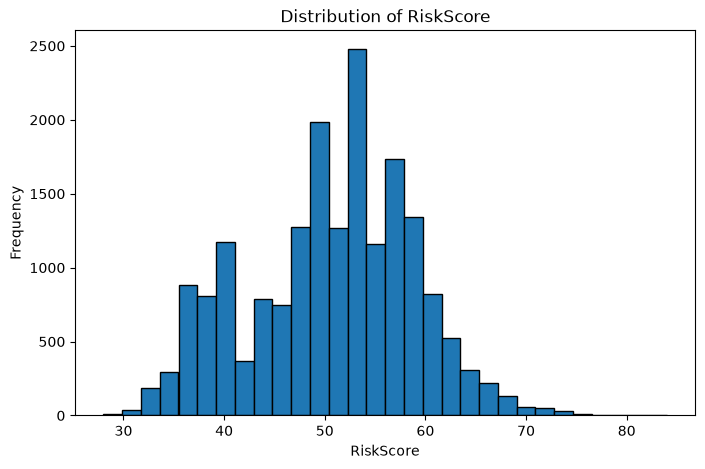

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(
    cleaned_df["RiskScore"].dropna(),
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of RiskScore")
plt.xlabel("RiskScore")
plt.ylabel("Frequency")
plt.show()

In [54]:
cleaned_df["MaritalStatus"].value_counts(dropna=False)

MaritalStatus
Married     10029
Single       6077
Divorced     2881
Widowed       998
NaN            15
Name: count, dtype: int64

In [55]:
marital_mode = cleaned_df["MaritalStatus"].mode()[0]

print("Most frequent MaritalStatus:", marital_mode)

Most frequent MaritalStatus: Married


In [56]:
cleaned_df["MaritalStatus"] = (
    cleaned_df["MaritalStatus"].fillna(marital_mode)
)

In [57]:
print(
    "Missing MaritalStatus after imputation:",
    cleaned_df["MaritalStatus"].isnull().sum()
)

Missing MaritalStatus after imputation: 0


In [58]:
cleaned_df["Experience"] = cleaned_df["Experience_ds2"].fillna(
    cleaned_df["Experience_ds1"]
)

print("Missing Experience:", cleaned_df["Experience"].isnull().sum())

Missing Experience: 0


In [59]:
cleaned_df[
    ["Experience_ds1", "Experience_ds2", "Experience"]
].isnull().sum()

Experience_ds1      0
Experience_ds2    666
Experience          0
dtype: int64

In [60]:
risk_median = cleaned_df["RiskScore"].median()

print("RiskScore median used for imputation:", risk_median)

cleaned_df["RiskScore"] = cleaned_df["RiskScore"].fillna(risk_median)

print(
    "Missing RiskScore after imputation:",
    cleaned_df["RiskScore"].isnull().sum()
)

RiskScore median used for imputation: 51.0
Missing RiskScore after imputation: 0


In [61]:
print(cleaned_df["MaritalStatus"].value_counts(dropna=False))

MaritalStatus
Married     10044
Single       6077
Divorced     2881
Widowed       998
Name: count, dtype: int64


In [62]:
marital_mode = cleaned_df["MaritalStatus"].mode()[0]

print("Mode:", marital_mode)

cleaned_df["MaritalStatus"] = cleaned_df["MaritalStatus"].fillna(
    marital_mode
)

print(
    "Missing MaritalStatus:",
    cleaned_df["MaritalStatus"].isnull().sum()
)

Mode: Married
Missing MaritalStatus: 0


In [63]:
print("Remaining conventional missing values:")
print(cleaned_df.isnull().sum()[cleaned_df.isnull().sum() > 0])

Remaining conventional missing values:
Experience_ds2    666
dtype: int64


In [64]:
print("Total missing values:", cleaned_df.isnull().sum().sum())

Total missing values: 666


In [65]:
cleaned_df.drop(
    columns=["Experience_ds1", "Experience_ds2"],
    inplace=True
)

print([col for col in cleaned_df.columns if "Experience" in col])

['Experience']


In [66]:
print(cleaned_df[
    ["ApplicationDate_ds1", "ApplicationDate_ds2"]
].head(10))

  ApplicationDate_ds1 ApplicationDate_ds2
0          01-01-2018          01-01-2018
1          02-01-2018          02-01-2018
2          03-01-2018          03-01-2018
3          04-01-2018          04-01-2018
4          05-01-2018          05-01-2018
5          06-01-2018          06-01-2018
6          07-01-2018          07-01-2018
7          08-01-2018          08-01-2018
8          09-01-2018          09-01-2018
9          10-01-2018          10-01-2018


In [67]:
matching_dates = (
    cleaned_df["ApplicationDate_ds1"]
    == cleaned_df["ApplicationDate_ds2"]
).sum()

print("Total records:", len(cleaned_df))
print("Matching application dates:", matching_dates)
print("Non-matching application dates:", len(cleaned_df) - matching_dates)
print(
    "Match percentage:",
    (matching_dates / len(cleaned_df)) * 100
)

Total records: 20000
Matching application dates: 2922
Non-matching application dates: 17078
Match percentage: 14.610000000000001


In [68]:
print(
    "Dataset 1 unique application dates:",
    cleaned_df["ApplicationDate_ds1"].nunique()
)

print(
    "Dataset 2 unique application dates:",
    cleaned_df["ApplicationDate_ds2"].nunique()
)

Dataset 1 unique application dates: 2922
Dataset 2 unique application dates: 20000


In [69]:
cleaned_df["ApplicationDate_ds1"] = pd.to_datetime(
    cleaned_df["ApplicationDate_ds1"],
    dayfirst=True,
    errors="coerce"
)

cleaned_df["ApplicationDate_ds2"] = pd.to_datetime(
    cleaned_df["ApplicationDate_ds2"],
    dayfirst=True,
    errors="coerce"
)

In [70]:
print("Dataset 1:")
print("Earliest date:", cleaned_df["ApplicationDate_ds1"].min())
print("Latest date:", cleaned_df["ApplicationDate_ds1"].max())
print("Unique dates:", cleaned_df["ApplicationDate_ds1"].nunique())

print("\nDataset 2:")
print("Earliest date:", cleaned_df["ApplicationDate_ds2"].min())
print("Latest date:", cleaned_df["ApplicationDate_ds2"].max())
print("Unique dates:", cleaned_df["ApplicationDate_ds2"].nunique())

Dataset 1:
Earliest date: 2018-01-01 00:00:00
Latest date: 2025-12-31 00:00:00
Unique dates: 2922

Dataset 2:
Earliest date: 2018-01-01 00:00:00
Latest date: 2072-10-03 00:00:00
Unique dates: 20000


In [71]:
date_range_ds1 = (
    cleaned_df["ApplicationDate_ds1"].max()
    - cleaned_df["ApplicationDate_ds1"].min()
)

date_range_ds2 = (
    cleaned_df["ApplicationDate_ds2"].max()
    - cleaned_df["ApplicationDate_ds2"].min()
)

print("Dataset 1 date range:", date_range_ds1)
print("Dataset 2 date range:", date_range_ds2)

Dataset 1 date range: 2921 days 00:00:00
Dataset 2 date range: 19999 days 00:00:00


In [72]:
cleaned_df[
    ["ID", "ApplicationDate_ds1", "ApplicationDate_ds2"]
].tail(10)

,ID,ApplicationDate_ds1,ApplicationDate_ds2
19990,B9992,2024-09-24,2072-09-24
19991,B9993,2024-09-25,2072-09-25
19992,B9994,2024-09-26,2072-09-26
19993,B9995,2024-09-27,2072-09-27
19994,B9996,2024-09-28,2072-09-28
19995,B9997,2024-09-29,2072-09-29
19996,B9998,2024-09-30,2072-09-30
19997,B9999,2024-10-01,2072-10-01
19998,C001,2024-10-02,2072-10-02
19999,C002,2024-10-03,2072-10-03


In [73]:
# Retain the application date consistent with the stated 96-month period
cleaned_df.rename(
    columns={"ApplicationDate_ds1": "ApplicationDate"},
    inplace=True
)

# Remove the inconsistent duplicate date column
cleaned_df.drop(
    columns=["ApplicationDate_ds2"],
    inplace=True
)

In [74]:
print([col for col in cleaned_df.columns if "ApplicationDate" in col])

print(
    "Application date range:",
    cleaned_df["ApplicationDate"].min(),
    "to",
    cleaned_df["ApplicationDate"].max()
)

['ApplicationDate']
Application date range: 2018-01-01 00:00:00 to 2025-12-31 00:00:00


In [75]:
print("Duplicate rows:", cleaned_df.duplicated().sum())
print("Duplicate IDs:", cleaned_df["ID"].duplicated().sum())

Duplicate rows: 0
Duplicate IDs: 0


In [76]:
print("Cleaned dataset shape:", cleaned_df.shape)
print("\nColumns:")
print(cleaned_df.columns.tolist())

Cleaned dataset shape: (20000, 31)

Columns:
['ID', 'ApplicationDate', 'AnnualIncome', 'EmploymentStatus', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'NumberOfOpenCreditLines', 'BankruptcyHistory', 'PreviousLoanDefaults', 'LengthOfCreditHistory', 'CheckingAccountBalance', 'TotalLiabilities', 'NetWorth', 'LoanApproved', 'Age', 'CreditScore', 'EducationLevel', 'LoanAmount', 'MaritalStatus', 'HomeOwnershipStatus', 'CreditCardUtilizationRate', 'NumberOfCreditInquiries', 'LoanPurpose', 'PaymentHistory', 'SavingsAccountBalance', 'TotalAssets', 'JobTenure', 'InterestRate', 'RiskScore', 'Experience']


In [77]:
cleaned_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   ID                         20000 non-null  str           
 1   ApplicationDate            20000 non-null  datetime64[us]
 2   AnnualIncome               20000 non-null  int64         
 3   EmploymentStatus           20000 non-null  str           
 4   LoanDuration               20000 non-null  int64         
 5   NumberOfDependents         20000 non-null  int64         
 6   MonthlyDebtPayments        20000 non-null  int64         
 7   NumberOfOpenCreditLines    20000 non-null  int64         
 8   BankruptcyHistory          20000 non-null  int64         
 9   PreviousLoanDefaults       20000 non-null  int64         
 10  LengthOfCreditHistory      20000 non-null  int64         
 11  CheckingAccountBalance     20000 non-null  int64         
 12  TotalLiabilitie

In [78]:
columns_to_check = [
    "AnnualIncome",
    "LoanAmount",
    "LoanDuration",
    "MonthlyDebtPayments",
    "InterestRate"
]

cleaned_df[columns_to_check].describe().T

,count,mean,std,min,25%,50%,75%,max
AnnualIncome,20000.0,59161.47355,40350.845168,15000.00,31679.00,48566.00,74391.00,485341.00
LoanAmount,20000.0,24882.86780,13427.421217,3674.00,15575.00,21914.50,30835.00,184732.00
LoanDuration,20000.0,54.05700,24.664857,12.00,36.00,48.00,72.00,120.00
MonthlyDebtPayments,20000.0,454.29270,240.507609,50.00,286.00,402.00,564.00,2919.00
InterestRate,20000.0,23.90604,4.220532,11.33,20.91,23.53,26.55,44.67


In [79]:
for col in columns_to_check:
    print(f"\n{col}")
    print("Minimum:", cleaned_df[col].min())
    print("Maximum:", cleaned_df[col].max())
    print("Median:", cleaned_df[col].median())


AnnualIncome
Minimum: 15000
Maximum: 485341
Median: 48566.0

LoanAmount
Minimum: 3674
Maximum: 184732
Median: 21914.5

LoanDuration
Minimum: 12
Maximum: 120
Median: 48.0

MonthlyDebtPayments
Minimum: 50
Maximum: 2919
Median: 402.0

InterestRate
Minimum: 11.33
Maximum: 44.67
Median: 23.53


In [80]:
cleaned_df["MonthlyIncome"] = (
    cleaned_df["AnnualIncome"] / 12
)

cleaned_df[
    ["AnnualIncome", "MonthlyIncome"]
].head()

,AnnualIncome,MonthlyIncome
0,39948,3329.000000
1,39709,3309.083333
2,40724,3393.666667
3,69084,5757.000000
4,103264,8605.333333


In [81]:
cleaned_df["MonthlyIncome"].describe()

count    20000.000000
mean      4930.122796
std       3362.570431
min       1250.000000
25%       2639.916667
50%       4047.166667
75%       6199.250000
max      40445.083333
Name: MonthlyIncome, dtype: float64

In [82]:
monthly_interest_rate = (
    cleaned_df["InterestRate"] / 100 / 12
)

In [83]:
cleaned_df["MonthlyLoanPayment"] = (
    cleaned_df["LoanAmount"]
    * (
        monthly_interest_rate
        * (1 + monthly_interest_rate)
        ** cleaned_df["LoanDuration"]
    )
    / (
        (1 + monthly_interest_rate)
        ** cleaned_df["LoanDuration"]
        - 1
    )
)

In [84]:
cleaned_df[
    [
        "LoanAmount",
        "LoanDuration",
        "InterestRate",
        "MonthlyLoanPayment"
    ]
].head()

,LoanAmount,LoanDuration,InterestRate,MonthlyLoanPayment
0,13152,48,22.75,419.741550
1,26045,48,20.10,793.947113
2,17627,36,21.25,666.363154
3,37898,96,30.09,1047.478283
4,9184,36,17.59,330.137727


In [85]:
cleaned_df["MonthlyLoanPayment"].describe()

count    20000.000000
mean       911.536396
std        674.556473
min         97.024487
25%        493.735752
50%        728.473546
75%       1112.675952
max      10892.286150
Name: MonthlyLoanPayment, dtype: float64

In [86]:
cleaned_df["TotalDebtToIncomeRatio"] = (
    (
        cleaned_df["MonthlyLoanPayment"]
        + cleaned_df["MonthlyDebtPayments"]
    )
    * 100
    / cleaned_df["MonthlyIncome"]
)

In [87]:
cleaned_df[
    [
        "MonthlyIncome",
        "MonthlyLoanPayment",
        "MonthlyDebtPayments",
        "TotalDebtToIncomeRatio"
    ]
].head(10)

,MonthlyIncome,MonthlyLoanPayment,MonthlyDebtPayments,TotalDebtToIncomeRatio
0,3329.000000,419.741550,183,18.105784
1,3309.083333,793.947113,496,38.982008
2,3393.666667,666.363154,902,46.214414
3,5757.000000,1047.478283,755,31.309333
4,8605.333333,330.137727,274,7.020503
5,14859.166667,385.576019,732,7.521122
6,4270.833333,391.251936,337,17.051753
7,8112.083333,1827.347863,288,26.076506
8,9736.750000,1762.065987,638,24.649560
9,3384.583333,2353.491518,704,90.335832


In [88]:
cleaned_df["MonthlyIncome"] = (
    cleaned_df["MonthlyIncome"].round(2)
)

cleaned_df["MonthlyLoanPayment"] = (
    cleaned_df["MonthlyLoanPayment"].round(2)
)

cleaned_df["TotalDebtToIncomeRatio"] = (
    cleaned_df["TotalDebtToIncomeRatio"].round(2)
)

In [89]:
cleaned_df[
    [
        "AnnualIncome",
        "MonthlyIncome",
        "LoanAmount",
        "InterestRate",
        "LoanDuration",
        "MonthlyLoanPayment",
        "MonthlyDebtPayments",
        "TotalDebtToIncomeRatio"
    ]
].head(10)

,AnnualIncome,MonthlyIncome,LoanAmount,InterestRate,LoanDuration,MonthlyLoanPayment,MonthlyDebtPayments,TotalDebtToIncomeRatio
0,39948,3329.00,13152,22.75,48,419.74,183,18.11
1,39709,3309.08,26045,20.10,48,793.95,496,38.98
2,40724,3393.67,17627,21.25,36,666.36,902,46.21
3,69084,5757.00,37898,30.09,96,1047.48,755,31.31
4,103264,8605.33,9184,17.59,36,330.14,274,7.02
5,178310,14859.17,15433,21.76,72,385.58,732,7.52
6,51250,4270.83,12741,20.52,48,391.25,337,17.05
7,97345,8112.08,19634,20.91,12,1827.35,288,26.08
8,116841,9736.75,55353,29.15,60,1762.07,638,24.65
9,40615,3384.58,25443,19.72,12,2353.49,704,90.34


In [90]:
print(
    "Missing MonthlyIncome:",
    cleaned_df["MonthlyIncome"].isnull().sum()
)

print(
    "Missing MonthlyLoanPayment:",
    cleaned_df["MonthlyLoanPayment"].isnull().sum()
)

print(
    "Missing TotalDebtToIncomeRatio:",
    cleaned_df["TotalDebtToIncomeRatio"].isnull().sum()
)

Missing MonthlyIncome: 0
Missing MonthlyLoanPayment: 0
Missing TotalDebtToIncomeRatio: 0


In [91]:
print(
    "Infinite values:",
    np.isinf(
        cleaned_df[
            [
                "MonthlyIncome",
                "MonthlyLoanPayment",
                "TotalDebtToIncomeRatio"
            ]
        ]
    ).sum()
)

Infinite values: MonthlyIncome             0
MonthlyLoanPayment        0
TotalDebtToIncomeRatio    0
dtype: int64


In [92]:
cleaned_df[
    [
        "MonthlyIncome",
        "MonthlyLoanPayment",
        "TotalDebtToIncomeRatio"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
MonthlyIncome,20000.0,4930.122820,3362.570430,1250.00,2639.9175,4047.165,6199.25,40445.08
MonthlyLoanPayment,20000.0,911.536386,674.556480,97.02,493.7325,728.475,1112.68,10892.29
TotalDebtToIncomeRatio,20000.0,40.046541,33.823143,1.60,17.8600,30.100,50.75,464.76


In [93]:
outlier_columns = [
    "AnnualIncome",
    "LoanAmount",
    "Age",
    "Experience",
    "RiskScore",
    "InterestRate",
    "MonthlyDebtPayments",
    "MonthlyIncome",
    "MonthlyLoanPayment",
    "TotalDebtToIncomeRatio"
]

In [94]:
for col in outlier_columns:
    print(col, "->", col in cleaned_df.columns)

AnnualIncome -> True
LoanAmount -> True
Age -> True
Experience -> True
RiskScore -> True
InterestRate -> True
MonthlyDebtPayments -> True
MonthlyIncome -> True
MonthlyLoanPayment -> True
TotalDebtToIncomeRatio -> True


In [95]:
outlier_results = []

for col in outlier_columns:
    Q1 = cleaned_df[col].quantile(0.25)
    Q3 = cleaned_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = cleaned_df[
        (cleaned_df[col] < lower_bound) |
        (cleaned_df[col] > upper_bound)
    ]

    outlier_results.append({
        "Variable": col,
        "Lower Bound": round(lower_bound, 2),
        "Upper Bound": round(upper_bound, 2),
        "Outlier Count": len(outliers),
        "Outlier Percentage": round(
            len(outliers) / len(cleaned_df) * 100, 2
        )
    })

outlier_summary = pd.DataFrame(outlier_results)

outlier_summary

,Variable,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,AnnualIncome,-32389.00,138459.00,947,4.74
1,LoanAmount,-7315.00,53725.00,746,3.73
2,Age,8.00,72.00,64,0.32
3,Experience,-15.00,49.00,75,0.38
4,RiskScore,31.00,71.00,94,0.47
5,InterestRate,12.45,35.01,221,1.10
6,MonthlyDebtPayments,-131.00,981.00,744,3.72
7,MonthlyIncome,-2699.08,11538.25,947,4.74
8,MonthlyLoanPayment,-434.69,2041.10,1089,5.45
9,TotalDebtToIncomeRatio,-31.48,100.08,1146,5.73


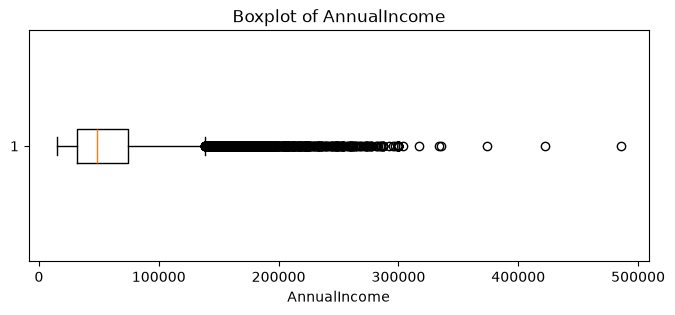

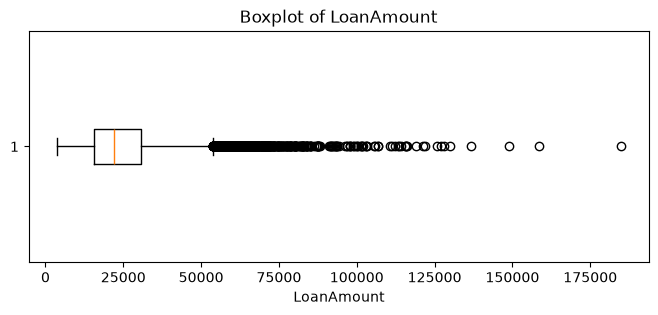

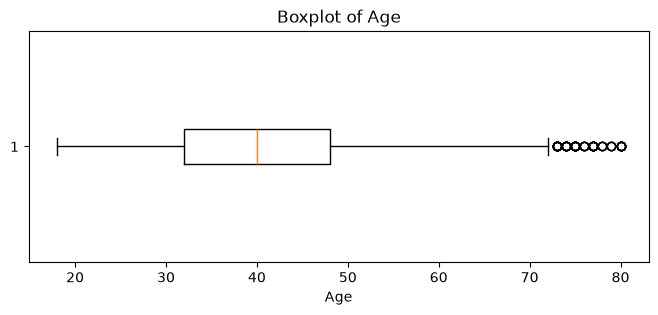

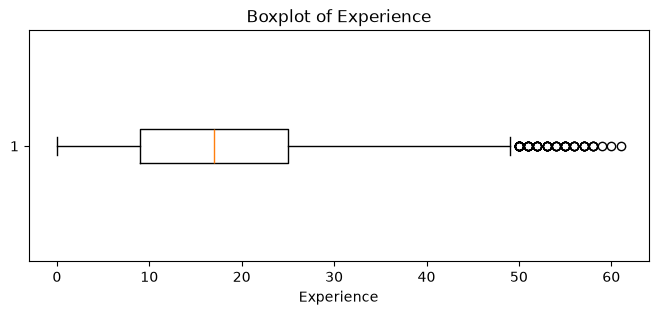

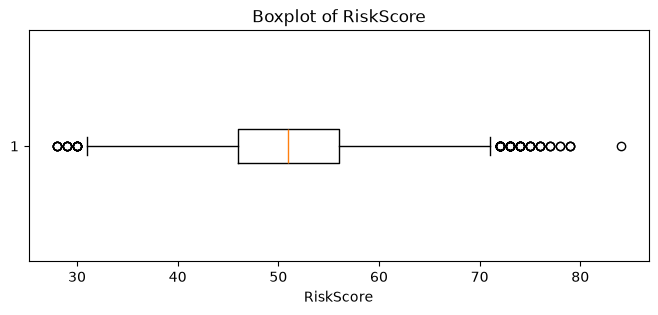

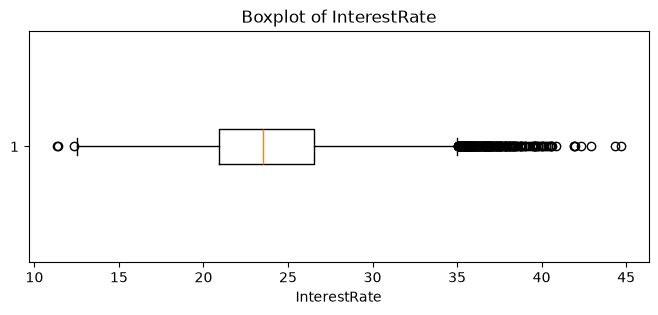

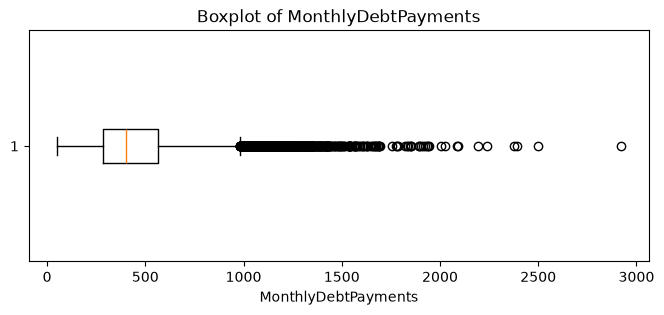

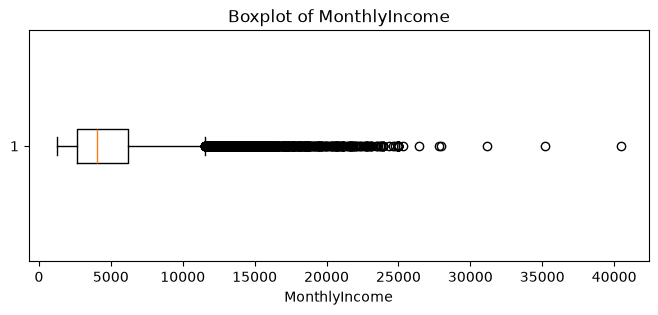

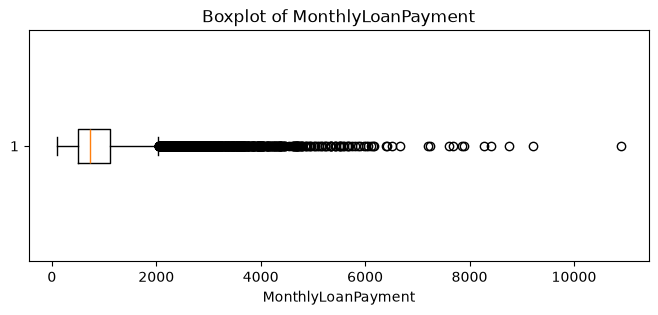

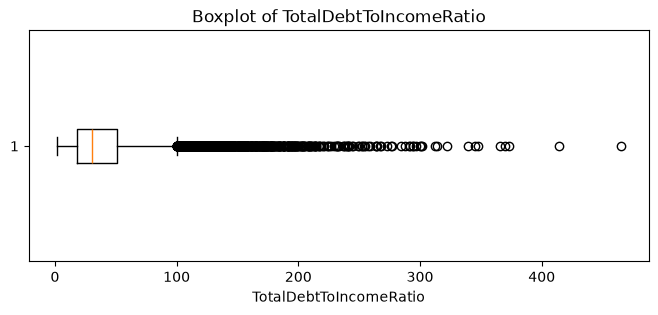

In [97]:
for col in outlier_columns:
    plt.figure(figsize=(8, 3))

    plt.boxplot(
        cleaned_df[col].dropna(),
        orientation="horizontal"
    )

    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)

    plt.show()

In [98]:
cleaned_df.nlargest(
    10,
    "TotalDebtToIncomeRatio"
)[
    [
        "ID",
        "AnnualIncome",
        "MonthlyIncome",
        "LoanAmount",
        "MonthlyLoanPayment",
        "MonthlyDebtPayments",
        "TotalDebtToIncomeRatio",
        "LoanApproved"
    ]
]

,ID,AnnualIncome,MonthlyIncome,LoanAmount,MonthlyLoanPayment,MonthlyDebtPayments,TotalDebtToIncomeRatio,LoanApproved
11233,B1235,15000,1250.00,55940,5237.55,572,464.76,0
5879,A5880,15000,1250.00,113154,4546.81,632,414.30,0
10490,B492,27053,2254.42,82699,7899.44,519,373.42,0
15334,B5336,20027,1668.92,56981,5354.51,818,369.85,0
16703,B6705,15000,1250.00,42545,3956.83,614,365.67,0
6957,A6958,39654,3304.50,184732,10892.29,586,347.35,0
7460,A7461,15000,1250.00,75973,4128.73,181,344.78,0
16663,B6665,16344,1362.00,38099,3646.28,972,339.08,0
16538,B6540,15000,1250.00,38431,3583.25,447,322.42,0
14669,B4671,15251,1270.92,37791,3459.29,530,313.89,0


In [99]:
cleaned_df.nlargest(
    10,
    "AnnualIncome"
)[
    [
        "ID",
        "AnnualIncome",
        "LoanAmount",
        "TotalDebtToIncomeRatio",
        "LoanApproved"
    ]
]

,ID,AnnualIncome,LoanAmount,TotalDebtToIncomeRatio,LoanApproved
15066,B5068,485341,35042,3.47,1
1499,A1500,422480,50214,4.81,1
2735,A2736,373724,13107,2.05,1
14448,B4450,335901,37774,5.76,1
4374,A4375,333715,32528,5.69,1
19600,B9602,317379,29404,6.57,1
13558,B3560,304122,9365,3.47,1
256,A257,300000,18698,7.20,1
1298,A1299,300000,29361,3.84,1
1344,A1345,300000,12314,3.78,1


In [100]:
cleaned_df.nlargest(
    10,
    "LoanAmount"
)[
    [
        "ID",
        "AnnualIncome",
        "LoanAmount",
        "MonthlyLoanPayment",
        "LoanApproved"
    ]
]

,ID,AnnualIncome,LoanAmount,MonthlyLoanPayment,LoanApproved
6957,A6958,39654,184732,10892.29,0
747,A748,81960,158686,4752.13,0
14507,B4509,50654,148776,5974.54,0
18435,B8437,104619,136565,6011.86,0
15101,B5103,30065,129860,5147.48,0
5845,A5846,30141,127945,4674.75,0
17020,B7022,38197,127011,7234.94,0
3012,A3013,56153,125733,4136.89,0
10435,B437,205609,121782,3440.44,0
4402,A4403,34819,121126,4882.70,0


In [101]:
print("Age minimum:", cleaned_df["Age"].min())
print("Age maximum:", cleaned_df["Age"].max())

cleaned_df.loc[
    (cleaned_df["Age"] < 18) |
    (cleaned_df["Age"] > 100),
    ["ID", "Age"]
]

Age minimum: 18
Age maximum: 80


,ID,Age


In [102]:
print("Experience minimum:", cleaned_df["Experience"].min())
print("Experience maximum:", cleaned_df["Experience"].max())

Experience minimum: 0.0
Experience maximum: 61.0


In [103]:
invalid_experience = cleaned_df[
    (cleaned_df["Experience"] < 0) |
    (cleaned_df["Experience"] > cleaned_df["Age"])
]

print(
    "Records where Experience is negative or greater than Age:",
    len(invalid_experience)
)

invalid_experience[
    ["ID", "Age", "Experience"]
].head(20)

Records where Experience is negative or greater than Age: 0


,ID,Age,Experience


In [104]:
print("RiskScore minimum:", cleaned_df["RiskScore"].min())
print("RiskScore maximum:", cleaned_df["RiskScore"].max())

cleaned_df["RiskScore"].describe()

RiskScore minimum: 28.0
RiskScore maximum: 84.0


count    20000.00000
mean        50.60625
std          7.90588
min         28.00000
25%         46.00000
50%         51.00000
75%         56.00000
max         84.00000
Name: RiskScore, dtype: float64

In [105]:
financial_columns = [
    "AnnualIncome",
    "LoanAmount",
    "MonthlyDebtPayments",
    "MonthlyIncome",
    "MonthlyLoanPayment"
]

for col in financial_columns:
    print(
        col,
        "- Negative:",
        (cleaned_df[col] < 0).sum(),
        "| Zero:",
        (cleaned_df[col] == 0).sum()
    )

AnnualIncome - Negative: 0 | Zero: 0
LoanAmount - Negative: 0 | Zero: 0
MonthlyDebtPayments - Negative: 0 | Zero: 0
MonthlyIncome - Negative: 0 | Zero: 0
MonthlyLoanPayment - Negative: 0 | Zero: 0


In [106]:
high_dti = cleaned_df[
    cleaned_df["TotalDebtToIncomeRatio"] > 100
]

print("Applicants with DTI > 100%:", len(high_dti))

print("\nLoan approval distribution:")
print(
    high_dti["LoanApproved"].value_counts()
)

print("\nApproval rate for DTI > 100%:")
print(
    high_dti["LoanApproved"].mean() * 100
)

Applicants with DTI > 100%: 1150

Loan approval distribution:
LoanApproved
0    1149
1       1
Name: count, dtype: int64

Approval rate for DTI > 100%:
0.08695652173913043


In [ ]:
#### Outlier Treatment Decision

In [107]:
print("Final dataset shape:", cleaned_df.shape)

print(
    "Total missing values:",
    cleaned_df.isnull().sum().sum()
)

print(
    "Duplicate rows:",
    cleaned_df.duplicated().sum()
)

print(
    "Duplicate IDs:",
    cleaned_df["ID"].duplicated().sum()
)

Final dataset shape: (20000, 34)
Total missing values: 0
Duplicate rows: 0
Duplicate IDs: 0


In [108]:
cleaned_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 34 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   ID                         20000 non-null  str           
 1   ApplicationDate            20000 non-null  datetime64[us]
 2   AnnualIncome               20000 non-null  int64         
 3   EmploymentStatus           20000 non-null  str           
 4   LoanDuration               20000 non-null  int64         
 5   NumberOfDependents         20000 non-null  int64         
 6   MonthlyDebtPayments        20000 non-null  int64         
 7   NumberOfOpenCreditLines    20000 non-null  int64         
 8   BankruptcyHistory          20000 non-null  int64         
 9   PreviousLoanDefaults       20000 non-null  int64         
 10  LengthOfCreditHistory      20000 non-null  int64         
 11  CheckingAccountBalance     20000 non-null  int64         
 12  TotalLiabilitie

In [109]:
required_columns = [
    "ApplicationDate",
    "Experience",
    "RiskScore",
    "MonthlyIncome",
    "MonthlyLoanPayment",
    "TotalDebtToIncomeRatio"
]

for col in required_columns:
    print(
        col,
        "->",
        col in cleaned_df.columns,
        "|",
        cleaned_df[col].dtype
    )

ApplicationDate -> True | datetime64[us]
Experience -> True | float64
RiskScore -> True | float64
MonthlyIncome -> True | float64
MonthlyLoanPayment -> True | float64
TotalDebtToIncomeRatio -> True | float64


In [110]:
cleaned_df.to_csv(
    "../data/Loan_Approval_Cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [111]:
cleaned_check = pd.read_csv(
    "../data/Loan_Approval_Cleaned.csv"
)

print("Saved dataset shape:", cleaned_check.shape)
print(
    "Total missing values:",
    cleaned_check.isnull().sum().sum()
)

cleaned_check.head()

Saved dataset shape: (20000, 34)
Total missing values: 0


,ID,ApplicationDate,AnnualIncome,EmploymentStatus,LoanDuration,NumberOfDependents,MonthlyDebtPayments,NumberOfOpenCreditLines,BankruptcyHistory,PreviousLoanDefaults,LengthOfCreditHistory,CheckingAccountBalance,TotalLiabilities,NetWorth,LoanApproved,Age,CreditScore,EducationLevel,LoanAmount,MaritalStatus,HomeOwnershipStatus,CreditCardUtilizationRate,NumberOfCreditInquiries,LoanPurpose,PaymentHistory,SavingsAccountBalance,TotalAssets,JobTenure,InterestRate,RiskScore,Experience,MonthlyIncome,MonthlyLoanPayment,TotalDebtToIncomeRatio
0,A001,2018-01-01,39948,Employed,48,2,183,1,0,0,9,1202,19183,126928,0,45,617,Master,13152,Married,Own,35.40,2,Home,29,7632,146111,11,22.75,49.0,22.0,3329.00,419.74,18.11
1,A002,2018-01-02,39709,Employed,48,1,496,5,0,0,9,3460,9595,43609,0,38,628,Associate,26045,Single,Mortgage,8.78,3,Debt Consolidation,21,4627,53204,3,20.10,51.0,15.0,3309.08,793.95,38.98
2,A003,2018-01-03,40724,Employed,36,2,902,2,0,0,22,895,128874,5205,0,47,570,Bachelor,17627,Married,Rent,13.70,0,Education,20,886,25176,6,21.25,51.0,26.0,3393.67,666.36,46.21
3,A004,2018-01-04,69084,Employed,96,1,755,2,0,0,10,1217,5370,99452,0,58,545,High School,37898,Single,Mortgage,2.67,1,Home,27,1675,104822,5,30.09,54.0,34.0,5757.00,1047.48,31.31
4,A005,2018-01-05,103264,Employed,36,1,274,0,0,0,27,4981,17286,227019,1,37,594,Associate,9184,Married,Mortgage,3.20,0,Debt Consolidation,26,1555,244305,5,17.59,36.0,17.0,8605.33,330.14,7.02


In [ ]:
### 2.3 Statistical, Computation-Based Analysis and Visualisation


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

cleaned_df = pd.read_csv(
    "../data/Loan_Approval_Cleaned.csv",
    parse_dates=["ApplicationDate"]
)

print("Dataset shape:", cleaned_df.shape)
cleaned_df.head()

Dataset shape: (20000, 34)


,ID,ApplicationDate,AnnualIncome,EmploymentStatus,LoanDuration,NumberOfDependents,MonthlyDebtPayments,NumberOfOpenCreditLines,BankruptcyHistory,PreviousLoanDefaults,...,PaymentHistory,SavingsAccountBalance,TotalAssets,JobTenure,InterestRate,RiskScore,Experience,MonthlyIncome,MonthlyLoanPayment,TotalDebtToIncomeRatio
0,A001,2018-01-01,39948,Employed,48,2,183,1,0,0,...,29,7632,146111,11,22.75,49.0,22.0,3329.00,419.74,18.11
1,A002,2018-01-02,39709,Employed,48,1,496,5,0,0,...,21,4627,53204,3,20.10,51.0,15.0,3309.08,793.95,38.98
2,A003,2018-01-03,40724,Employed,36,2,902,2,0,0,...,20,886,25176,6,21.25,51.0,26.0,3393.67,666.36,46.21
3,A004,2018-01-04,69084,Employed,96,1,755,2,0,0,...,27,1675,104822,5,30.09,54.0,34.0,5757.00,1047.48,31.31
4,A005,2018-01-05,103264,Employed,36,1,274,0,0,0,...,26,1555,244305,5,17.59,36.0,17.0,8605.33,330.14,7.02


In [2]:
approval_counts = (
    cleaned_df["LoanApproved"]
    .value_counts()
    .sort_index()
)

approval_percentages = (
    cleaned_df["LoanApproved"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

print("Loan Approval Counts:")
print(approval_counts)

print("\nLoan Approval Percentages:")
print(approval_percentages.round(2))

Loan Approval Counts:
LoanApproved
0    15220
1     4780
Name: count, dtype: int64

Loan Approval Percentages:
LoanApproved
0    76.1
1    23.9
Name: proportion, dtype: float64


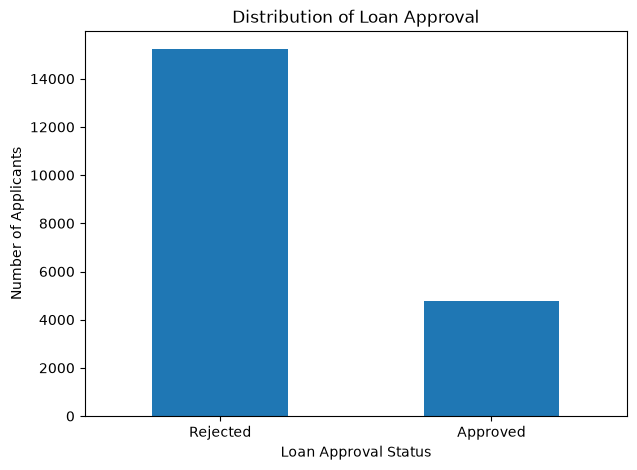

In [3]:
plt.figure(figsize=(7, 5))

approval_counts.plot(kind="bar")

plt.title("Distribution of Loan Approval")
plt.xlabel("Loan Approval Status")
plt.ylabel("Number of Applicants")
plt.xticks(
    ticks=[0, 1],
    labels=["Rejected", "Approved"],
    rotation=0
)

plt.show()

In [ ]:
# Most loans are rejected (76%) and approved (24%), proving there is a class imbalance, so check precision and recall instead of just accuracy.

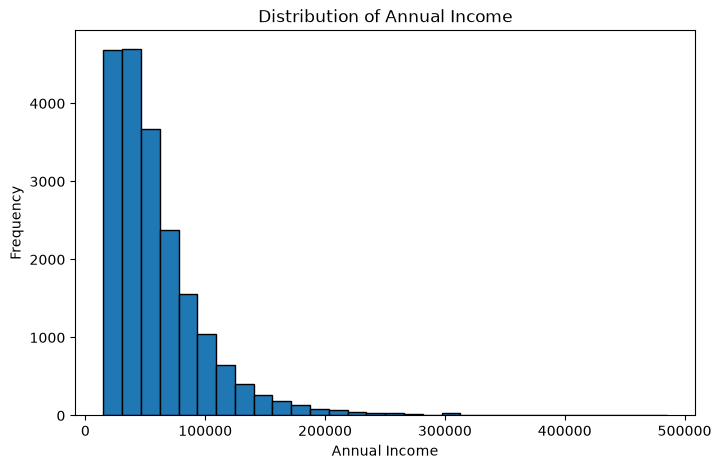

In [4]:
plt.figure(figsize=(8, 5))

plt.hist(
    cleaned_df["AnnualIncome"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Annual Income")
plt.xlabel("Annual Income")
plt.ylabel("Frequency")

plt.show()

In [5]:
print("Mean:", cleaned_df["AnnualIncome"].mean())
print("Median:", cleaned_df["AnnualIncome"].median())
print("Skewness:", cleaned_df["AnnualIncome"].skew())

Mean: 59161.47355
Median: 48566.0
Skewness: 2.0889479585248196


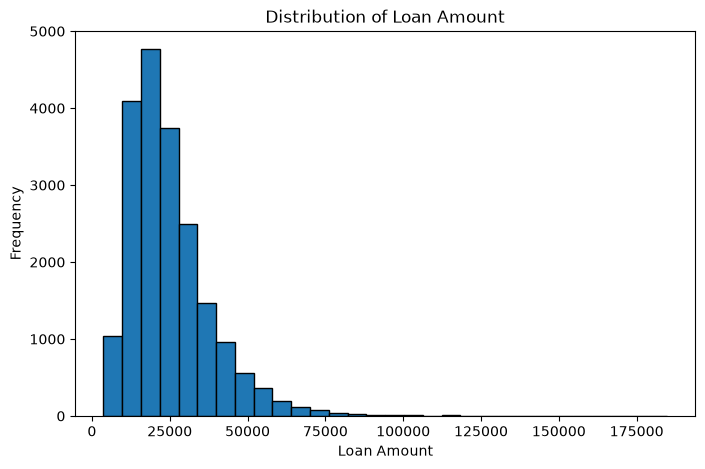

In [6]:
plt.figure(figsize=(8, 5))

plt.hist(
    cleaned_df["LoanAmount"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Loan Amount")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")

plt.show()

In [7]:
print("Mean:", cleaned_df["LoanAmount"].mean())
print("Median:", cleaned_df["LoanAmount"].median())
print("Skewness:", cleaned_df["LoanAmount"].skew())

Mean: 24882.8678
Median: 21914.5
Skewness: 1.833687791747409


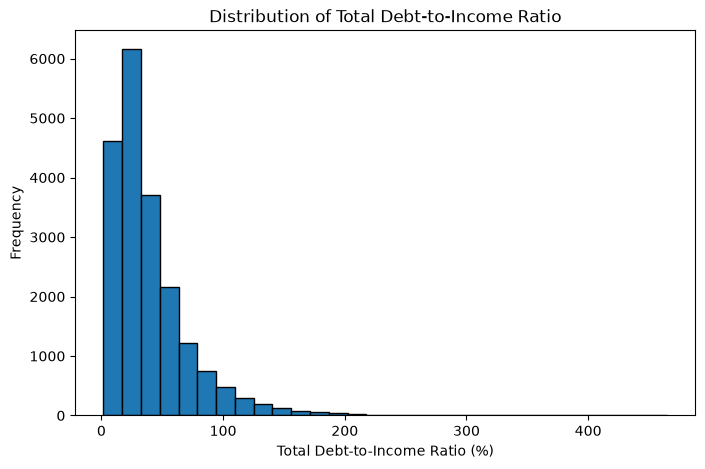

In [8]:
plt.figure(figsize=(8, 5))

plt.hist(
    cleaned_df["TotalDebtToIncomeRatio"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Total Debt-to-Income Ratio")
plt.xlabel("Total Debt-to-Income Ratio (%)")
plt.ylabel("Frequency")

plt.show()

In [9]:
cleaned_df["TotalDebtToIncomeRatio"].describe()

count    20000.000000
mean        40.046541
std         33.823143
min          1.600000
25%         17.860000
50%         30.100000
75%         50.750000
max        464.760000
Name: TotalDebtToIncomeRatio, dtype: float64

In [10]:
cleaned_df["EmploymentStatus"].value_counts()

EmploymentStatus
Employed         17036
Self-Employed     1573
Unemployed        1391
Name: count, dtype: int64

In [11]:
employment_approval = (
    cleaned_df
    .groupby("EmploymentStatus")["LoanApproved"]
    .mean()
    .sort_values(ascending=False) * 100
)

employment_approval

EmploymentStatus
Self-Employed    27.844882
Employed         24.002113
Unemployed       18.188354
Name: LoanApproved, dtype: float64

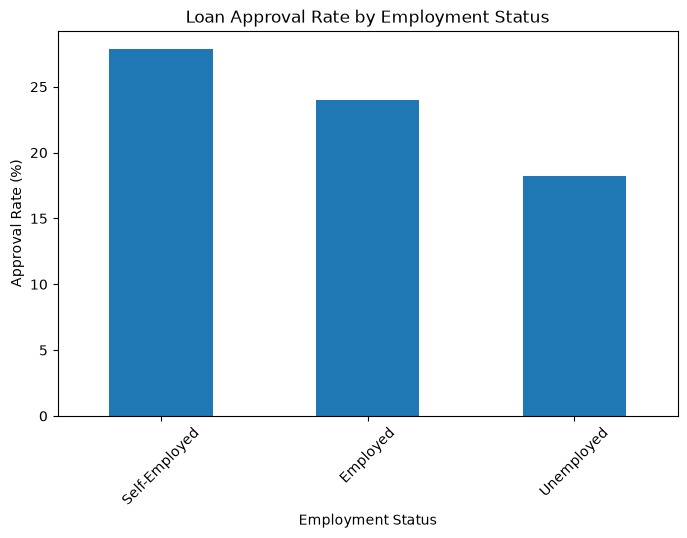

In [12]:
plt.figure(figsize=(8, 5))

employment_approval.plot(kind="bar")

plt.title("Loan Approval Rate by Employment Status")
plt.xlabel("Employment Status")
plt.ylabel("Approval Rate (%)")
plt.xticks(rotation=45)

plt.show()

In [ ]:
### Loan approval rates vary across employment-status categories, indicating that employment status is associated with the likelihood of approval. However, the differences are moderate compared with some of the numerical financial indicators, suggesting that employment status is likely to be one of several factors associated with the lending decision.

In [13]:
home_approval = (
    cleaned_df
    .groupby("HomeOwnershipStatus")["LoanApproved"]
    .mean()
    .sort_values(ascending=False) * 100
)

home_approval

HomeOwnershipStatus
Mortgage    25.154302
Own         24.885729
Rent        22.769837
Other       20.481336
Name: LoanApproved, dtype: float64

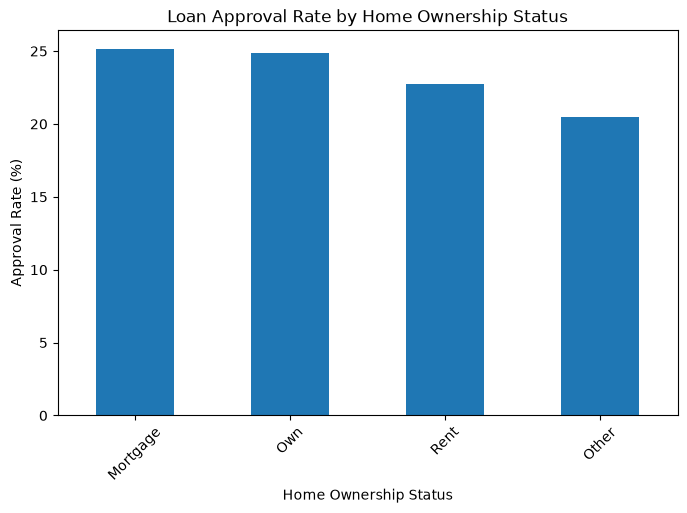

In [14]:
plt.figure(figsize=(8, 5))

home_approval.plot(kind="bar")

plt.title("Loan Approval Rate by Home Ownership Status")
plt.xlabel("Home Ownership Status")
plt.ylabel("Approval Rate (%)")
plt.xticks(rotation=45)

plt.show()

In [15]:
income_by_approval = cleaned_df.groupby(
    "LoanApproved"
)["AnnualIncome"].agg(
    ["mean", "median", "std"]
)

income_by_approval

,mean,median,std
LoanApproved,,,
0,45641.460907,40557.5,24079.007328
1,102210.551464,91269.5,50313.413141


<Figure size 800x500 with 0 Axes>

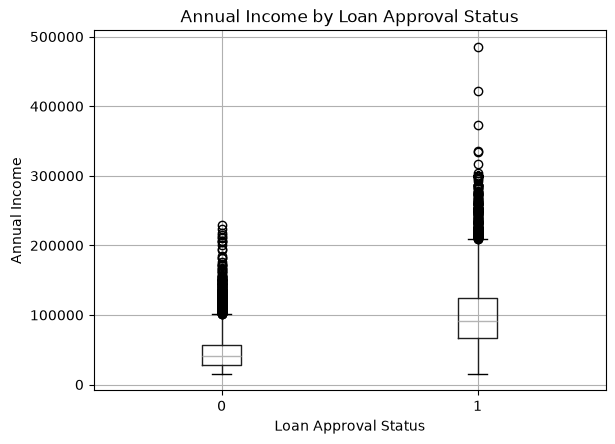

In [16]:
plt.figure(figsize=(8, 5))

cleaned_df.boxplot(
    column="AnnualIncome",
    by="LoanApproved"
)

plt.title("Annual Income by Loan Approval Status")
plt.suptitle("")
plt.xlabel("Loan Approval Status")
plt.ylabel("Annual Income")

plt.show()

In [17]:
risk_by_approval = cleaned_df.groupby(
    "LoanApproved"
)["RiskScore"].agg(
    ["mean", "median", "std"]
)

risk_by_approval

,mean,median,std
LoanApproved,,,
0,54.023587,54.0,5.341855
1,39.725105,40.0,3.882151


<Figure size 800x500 with 0 Axes>

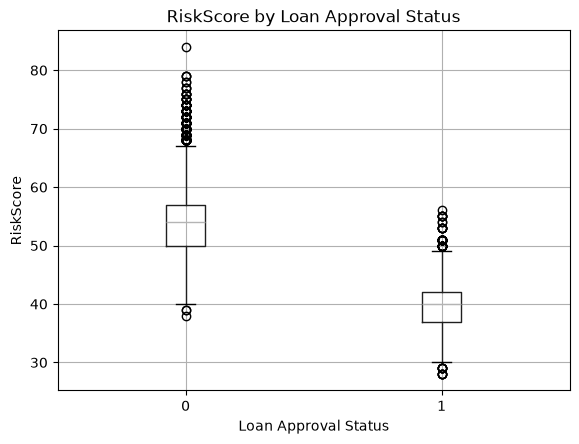

In [18]:
plt.figure(figsize=(8, 5))

cleaned_df.boxplot(
    column="RiskScore",
    by="LoanApproved"
)

plt.title("RiskScore by Loan Approval Status")
plt.suptitle("")
plt.xlabel("Loan Approval Status")
plt.ylabel("RiskScore")

plt.show()

In [19]:
dti_by_approval = cleaned_df.groupby(
    "LoanApproved"
)["TotalDebtToIncomeRatio"].agg(
    ["mean", "median", "std"]
)

dti_by_approval

,mean,median,std
LoanApproved,,,
0,47.808779,37.935,35.064685
1,15.330797,13.705,8.306191


In [ ]:
### Debt-to-income ratio shows a substantial difference between approved and rejected applicants. Rejected applicants have a mean Total Debt-to-Income Ratio of approximately 47.81%, compared with 15.33% for approved applicants. The corresponding medians are approximately 37.94% and 13.71%, respectively. This suggests that applicants with lower debt obligations relative to their income are considerably more likely to receive loan approval.

<Figure size 800x500 with 0 Axes>

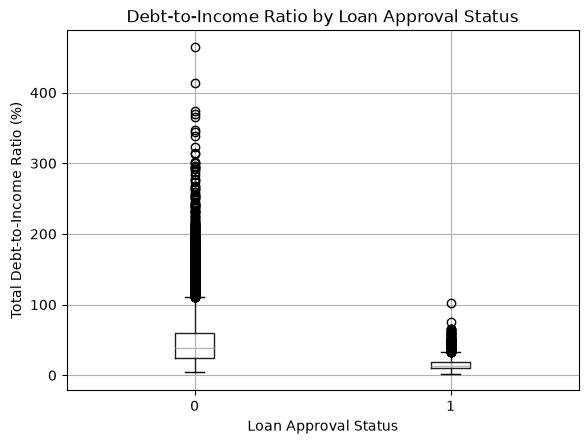

In [20]:
plt.figure(figsize=(8, 5))

cleaned_df.boxplot(
    column="TotalDebtToIncomeRatio",
    by="LoanApproved"
)

plt.title("Debt-to-Income Ratio by Loan Approval Status")
plt.suptitle("")
plt.xlabel("Loan Approval Status")
plt.ylabel("Total Debt-to-Income Ratio (%)")

plt.show()

In [21]:
correlation_columns = [
    "Age",
    "AnnualIncome",
    "Experience",
    "LoanAmount",
    "LoanDuration",
    "MonthlyDebtPayments",
    "CreditScore",
    "RiskScore",
    "InterestRate",
    "TotalAssets",
    "TotalLiabilities",
    "NetWorth",
    "MonthlyIncome",
    "MonthlyLoanPayment",
    "TotalDebtToIncomeRatio",
    "LoanApproved"
]

correlation_matrix = cleaned_df[
    correlation_columns
].corr()

correlation_matrix.round(2)

,Age,AnnualIncome,Experience,LoanAmount,LoanDuration,MonthlyDebtPayments,CreditScore,RiskScore,InterestRate,TotalAssets,TotalLiabilities,NetWorth,MonthlyIncome,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved
Age,1.00,0.14,0.98,-0.01,-0.01,0.02,0.32,-0.16,-0.20,0.01,-0.00,0.01,0.14,-0.02,-0.11,0.14
AnnualIncome,0.14,1.00,0.15,-0.00,0.00,-0.00,0.10,-0.49,-0.06,-0.01,-0.00,-0.00,1.00,-0.00,-0.54,0.60
Experience,0.98,0.15,1.00,-0.01,-0.01,0.02,0.33,-0.17,-0.21,0.01,-0.00,0.02,0.15,-0.02,-0.11,0.14
LoanAmount,-0.01,-0.00,-0.01,1.00,-0.00,0.02,-0.01,0.14,0.32,-0.00,0.00,-0.00,-0.00,0.78,0.46,-0.24
LoanDuration,-0.01,0.00,-0.01,-0.00,1.00,0.00,-0.00,0.06,0.49,-0.01,0.00,-0.01,0.00,-0.39,-0.21,-0.09
MonthlyDebtPayments,0.02,-0.00,0.02,0.02,0.00,1.00,0.01,0.04,0.00,0.00,-0.00,0.00,-0.00,0.02,0.22,-0.07
CreditScore,0.32,0.10,0.33,-0.01,-0.00,0.01,1.00,-0.24,-0.60,0.00,-0.01,0.00,0.10,-0.06,-0.12,0.14
RiskScore,-0.16,-0.49,-0.17,0.14,0.06,0.04,-0.24,1.00,0.27,-0.30,0.05,-0.30,-0.49,0.12,0.34,-0.77
InterestRate,-0.20,-0.06,-0.21,0.32,0.49,0.00,-0.60,0.27,1.00,-0.01,0.01,-0.01,-0.06,0.13,0.13,-0.30
TotalAssets,0.01,-0.01,0.01,-0.00,-0.01,0.00,0.00,-0.30,-0.01,1.00,-0.00,0.98,-0.01,-0.00,-0.01,0.18


In [24]:
!pip install seaborn
import seaborn as sns

Defaulting to user installation because normal site-packages is not writeable


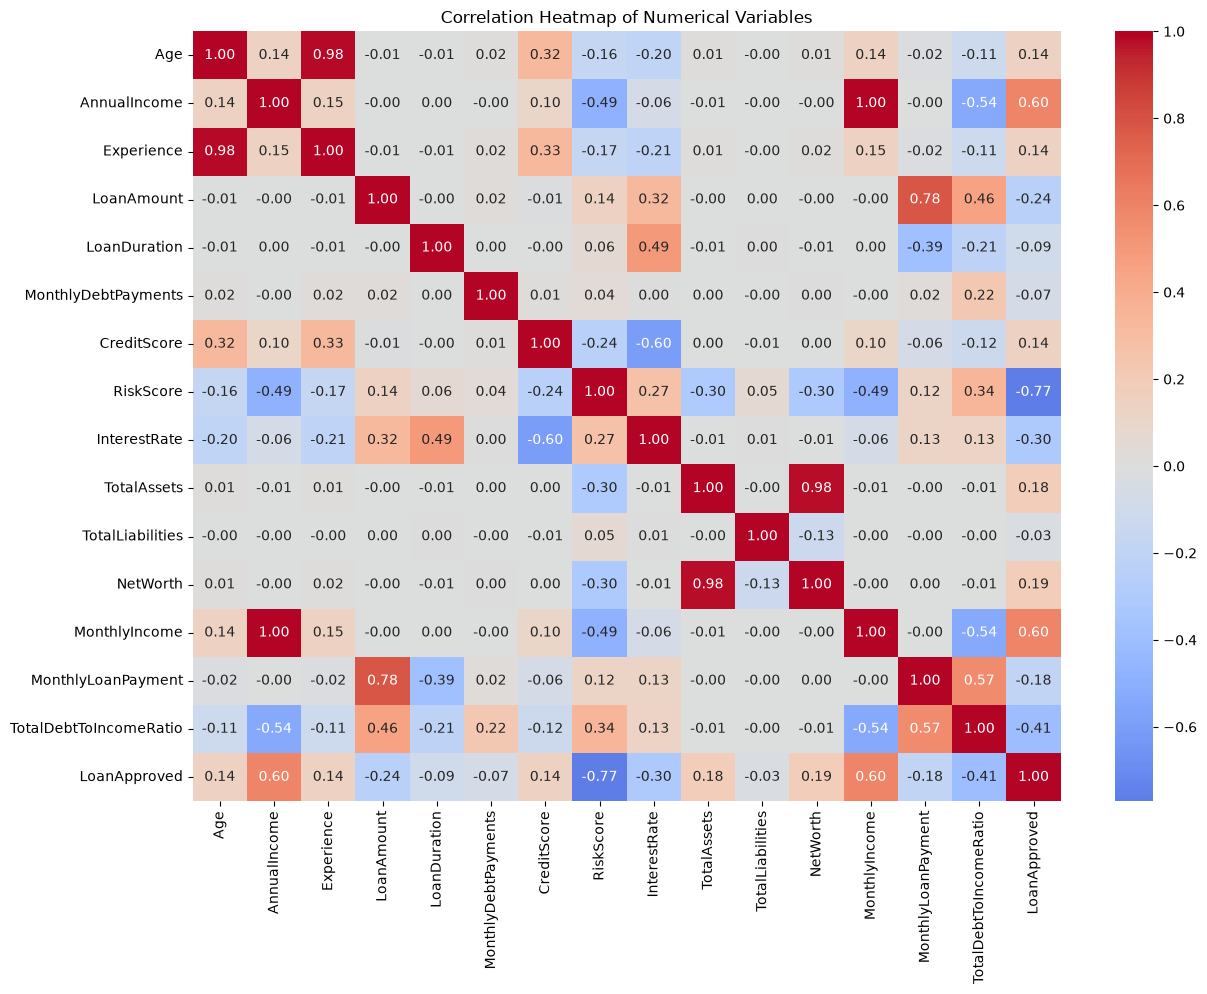

In [26]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Numerical Variables")

plt.show()

In [27]:
approval_correlations = (
    correlation_matrix["LoanApproved"]
    .drop("LoanApproved")
    .sort_values(key=abs, ascending=False)
)

approval_correlations

RiskScore                -0.771333
MonthlyIncome             0.597900
AnnualIncome              0.597900
TotalDebtToIncomeRatio   -0.409522
InterestRate             -0.301632
LoanAmount               -0.239496
NetWorth                  0.187892
MonthlyLoanPayment       -0.184263
TotalAssets               0.184011
CreditScore               0.142000
Age                       0.141029
Experience                0.140755
LoanDuration             -0.094558
MonthlyDebtPayments      -0.070415
TotalLiabilities         -0.029434
Name: LoanApproved, dtype: float64

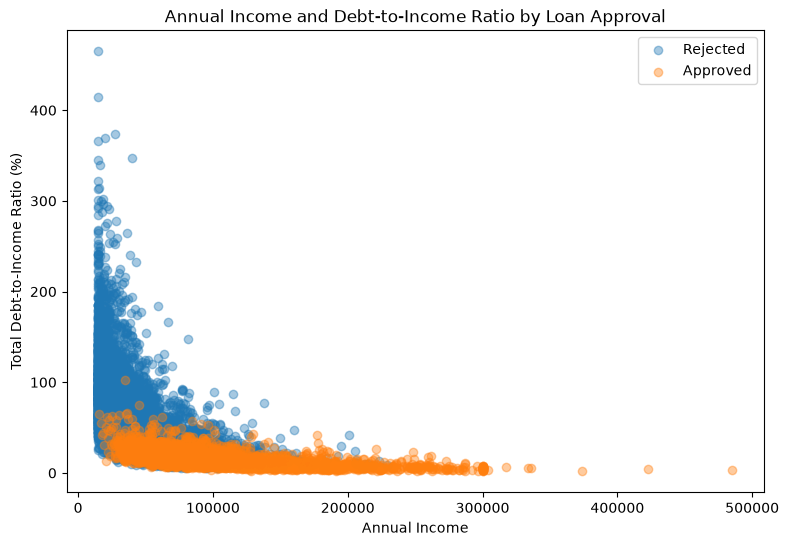

In [28]:
plt.figure(figsize=(9, 6))

for status, label in [(0, "Rejected"), (1, "Approved")]:
    subset = cleaned_df[
        cleaned_df["LoanApproved"] == status
    ]

    plt.scatter(
        subset["AnnualIncome"],
        subset["TotalDebtToIncomeRatio"],
        alpha=0.4,
        label=label
    )

plt.title(
    "Annual Income and Debt-to-Income Ratio by Loan Approval"
)

plt.xlabel("Annual Income")
plt.ylabel("Total Debt-to-Income Ratio (%)")

plt.legend()
plt.show()